In [33]:
import pandas as pd
import re

def parse_can_log(file_path):
    """Parse CAN log file and return a pandas DataFrame"""
    data = []
    
    with open(file_path, 'r') as f:
        for line in f:
            # Extract fields using regex
            match = re.search(r'Timestamp:\s([\d.]+)\s+ID:\s(\w+)\s+(\w+)\s+DLC:\s(\d+)\s+(.*)', line)
            if match:
                timestamp, can_id, flags, dlc, hex_data = match.groups()
                data.append({
                    'Timestamp': float(timestamp),
                    'ID': can_id,
                    'Flags': flags,
                    'DLC': int(dlc),
                    'Data': hex_data.strip()
                })
    
    df = pd.DataFrame(data)
    return df

# Usage
df = parse_can_log('dataset\\normal_run_data\\normal_run_data.txt')
print(df)

           Timestamp    ID Flags  DLC                     Data
0       1.479121e+09  0350   000    8  05 28 84 66 6d 00 00 a2
1       1.479121e+09  02c0   000    8  14 00 00 00 00 00 00 00
2       1.479121e+09  0430   000    8  00 00 00 00 00 00 00 00
3       1.479121e+09  04b1   000    8  00 00 00 00 00 00 00 00
4       1.479121e+09  01f1   000    8  00 00 00 00 00 00 00 00
...              ...   ...   ...  ...                      ...
988866  1.479122e+09  02b0   000    5           ac 05 0c 07 7f
988867  1.479122e+09  0316   000    8  05 38 10 0c 38 28 01 7a
988868  1.479122e+09  018f   000    8  fe 31 00 00 00 4b 00 00
988869  1.479122e+09  0260   000    8  32 38 39 30 ff 93 59 1c
988870  1.479122e+09  02a0   000    8  20 00 75 1d 01 04 dd 00

[988871 rows x 5 columns]


In [58]:
window_size = 10000  # Define the size of each window

id_groups = [df['ID'].iloc[i:i+window_size].tolist() for i in range(0, len(df), window_size)]
id_groups[:-10]  # Display the first 10 groups of IDs

[['0350',
  '02c0',
  '0430',
  '04b1',
  '01f1',
  '0153',
  '0002',
  '018f',
  '0130',
  '0131',
  '0140',
  '0260',
  '02a0',
  '0316',
  '0329',
  '0545',
  '02b0',
  '043f',
  '0370',
  '0440',
  '02c0',
  '0350',
  '04f0',
  '0002',
  '0153',
  '0316',
  '018f',
  '0260',
  '0130',
  '0131',
  '0140',
  '02a0',
  '0329',
  '0545',
  '02b0',
  '043f',
  '0370',
  '0440',
  '05f0',
  '02c0',
  '0350',
  '0430',
  '04b1',
  '01f1',
  '0153',
  '0002',
  '018f',
  '0260',
  '02a0',
  '0316',
  '0329',
  '0130',
  '0131',
  '0140',
  '0545',
  '02b0',
  '043f',
  '0370',
  '0440',
  '02c0',
  '0350',
  '0002',
  '0153',
  '0130',
  '0131',
  '0140',
  '018f',
  '0260',
  '02a0',
  '0316',
  '0329',
  '04f0',
  '0545',
  '02b0',
  '043f',
  '0370',
  '0440',
  '02c0',
  '0350',
  '0430',
  '04b1',
  '01f1',
  '0153',
  '0002',
  '018f',
  '0260',
  '02a0',
  '0316',
  '0329',
  '0130',
  '0131',
  '0140',
  '0545',
  '02b0',
  '043f',
  '0370',
  '0440',
  '02c0',
  '0350',
  '05a0',


In [59]:
from collections import Counter

window_freqs = [dict(Counter(window)) for window in id_groups]
window_freqs[:5]

[{'0350': 512,
  '02c0': 513,
  '0430': 256,
  '04b1': 256,
  '01f1': 256,
  '0153': 512,
  '0002': 512,
  '018f': 513,
  '0130': 512,
  '0131': 512,
  '0140': 512,
  '0260': 513,
  '02a0': 513,
  '0316': 513,
  '0329': 512,
  '0545': 512,
  '02b0': 512,
  '043f': 512,
  '0370': 512,
  '0440': 512,
  '04f0': 256,
  '05f0': 102,
  '05a0': 6,
  '05a2': 6,
  '0690': 51,
  '00a0': 51,
  '00a1': 51},
 {'0329': 513,
  '0350': 513,
  '0545': 513,
  '05f0': 103,
  '0430': 257,
  '04b1': 257,
  '01f1': 257,
  '0153': 513,
  '0002': 512,
  '0130': 512,
  '0131': 512,
  '0140': 512,
  '02c0': 512,
  '043f': 512,
  '0370': 512,
  '0440': 512,
  '0316': 512,
  '018f': 512,
  '0260': 512,
  '02a0': 512,
  '02b0': 511,
  '04f0': 256,
  '0690': 51,
  '00a0': 51,
  '00a1': 51,
  '05a0': 5,
  '05a2': 5},
 {'0002': 513,
  '02c0': 513,
  '02b0': 512,
  '0130': 512,
  '0131': 512,
  '0140': 512,
  '0316': 513,
  '018f': 513,
  '0260': 513,
  '02a0': 513,
  '0329': 513,
  '0545': 512,
  '043f': 512,
  '0440

In [60]:
window_avg_freqs = [pd.Series(list(freqs.values())).mean() for freqs in window_freqs]
window_std_freqs = [pd.Series(list(freqs.values())).std(ddof=0) for freqs in window_freqs]

window_avg_freqs[:10], window_std_freqs[:10]

([np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704),
  np.float64(370.3703703703704)],
 [np.float64(196.10015357769652),
  np.float64(196.06936568245965),
  np.float64(196.2915722702003),
  np.float64(195.9529701981893),
  np.float64(196.29176095389573),
  np.float64(196.21419666766445),
  np.float64(196.20456976370127),
  np.float64(196.11809521365743),
  np.float64(196.0227024169032),
  np.float64(196.2919496374098)])

In [61]:
avg_window_avg = sum(window_avg_freqs) / len(window_avg_freqs)
avg_window_std = sum(window_std_freqs) / len(window_std_freqs)

avg_window_avg, avg_window_std
print(f"Average of window average frequencies: {avg_window_avg}")
print(f"Average of window standard deviations: {avg_window_std}")

Average of window average frequencies: 369.9479985035535
Average of window standard deviations: 195.93207213137396


In [89]:
std_window_avg = sum(window_std_freqs) / len(window_std_freqs)
std_window_std = pd.Series(window_std_freqs).std(ddof=0)

print(f"Average of window standard deviations: {std_window_avg}")
print(f"Standard deviation of window standard deviations: {std_window_std}")

Average of window standard deviations: 195.93207213137396
Standard deviation of window standard deviations: 2.1923307428359804


In [138]:
def parse_can_csv(file_path):
    # try reading with a header first
    df_DoS = pd.read_csv(file_path, skipinitialspace=True)
    
    if 'ID dlc' in df_DoS.columns:
        df_DoS[['ID', 'DLC']] = df_DoS['ID dlc'].astype(str).str.split(r'\s+', n=1, expand=True)
        df_DoS = df_DoS.drop(columns=['ID dlc'])
    elif set(['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','attack/nonattack']).issubset(df_DoS.columns):
        df_DoS = df_DoS.rename(columns={'attack/nonattack': 'Attack'})
    else:
        names = ['Timestamp','ID','DLC','data1','data2','data3','data4','data5','data6','data7','data8','Attack']
        df_DoS = pd.read_csv(file_path, header=None, names=names, skipinitialspace=True)

    data_cols = [c for c in df_DoS.columns if c.lower().startswith('data')]
    df_DoS['Data'] = df_DoS[data_cols].astype(str).apply(
        lambda row: ' '.join(x for x in row if x not in ['', 'nan', 'NaN']),
        axis=1
    ).str.strip()

    df_DoS['Timestamp'] = pd.to_numeric(df_DoS['Timestamp'], errors='coerce')
    df_DoS['DLC'] = pd.to_numeric(df_DoS['DLC'], errors='coerce').astype('Int64')

    return df_DoS[['Timestamp','ID','DLC','Data','Attack']]

df_DoS = parse_can_csv(r'dataset\DoS_dataset.csv')
print(df_DoS.head())

      Timestamp    ID  DLC                     Data Attack
0  1.478198e+09  0316    8  05 21 68 09 21 21 00 6f      R
1  1.478198e+09  018f    8  fe 5b 00 00 00 3c 00 00      R
2  1.478198e+09  0260    8  19 21 22 30 08 8e 6d 3a      R
3  1.478198e+09  02a0    8  64 00 9a 1d 97 02 bd 00      R
4  1.478198e+09  0329    8  40 bb 7f 14 11 20 00 14      R


In [139]:

DoS_id_groups = [df_DoS['ID'].iloc[i:i+window_size].tolist() for i in range(0, len(df_DoS), window_size)]



DoS_window_freqs = [dict(Counter(window)) for window in DoS_id_groups]


DoS_window_avg_freqs = [pd.Series(list(freqs.values())).mean() for freqs in DoS_window_freqs]
DoS_window_std_freqs = [pd.Series(list(freqs.values())).std(ddof=0) for freqs in DoS_window_freqs]


In [140]:
# Create an array indicating if attack is present in each window
DoS_window_attack_flags = []

attack_present = False

count = 0
for type in df_DoS["Attack"]:
    if count % window_size == 0 and count != 0:
        DoS_window_attack_flags.append(attack_present)
        attack_present = False
    if type == "T":
        attack_present = True
    count += 1

# Append the last window's attack flag
DoS_window_attack_flags.append(attack_present)

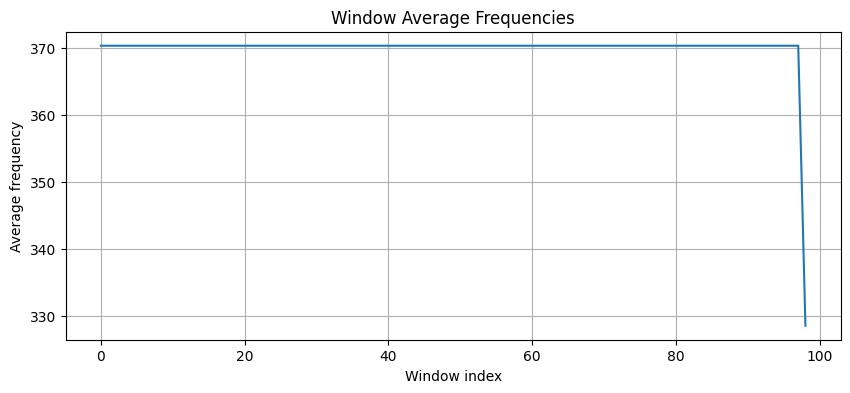

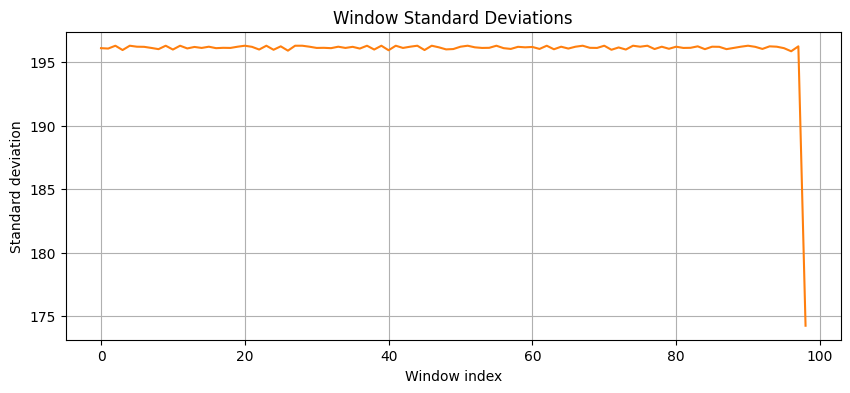

In [141]:
x = range(len(window_avg_freqs))

plt.figure(figsize=(10, 4))
plt.plot(x, window_avg_freqs, color='tab:blue')
plt.title('Window Average Frequencies')
plt.xlabel('Window index')
plt.ylabel('Average frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, window_std_freqs, color='tab:orange')
plt.title('Window Standard Deviations')
plt.xlabel('Window index')
plt.ylabel('Standard deviation')
plt.grid(True)
plt.show()

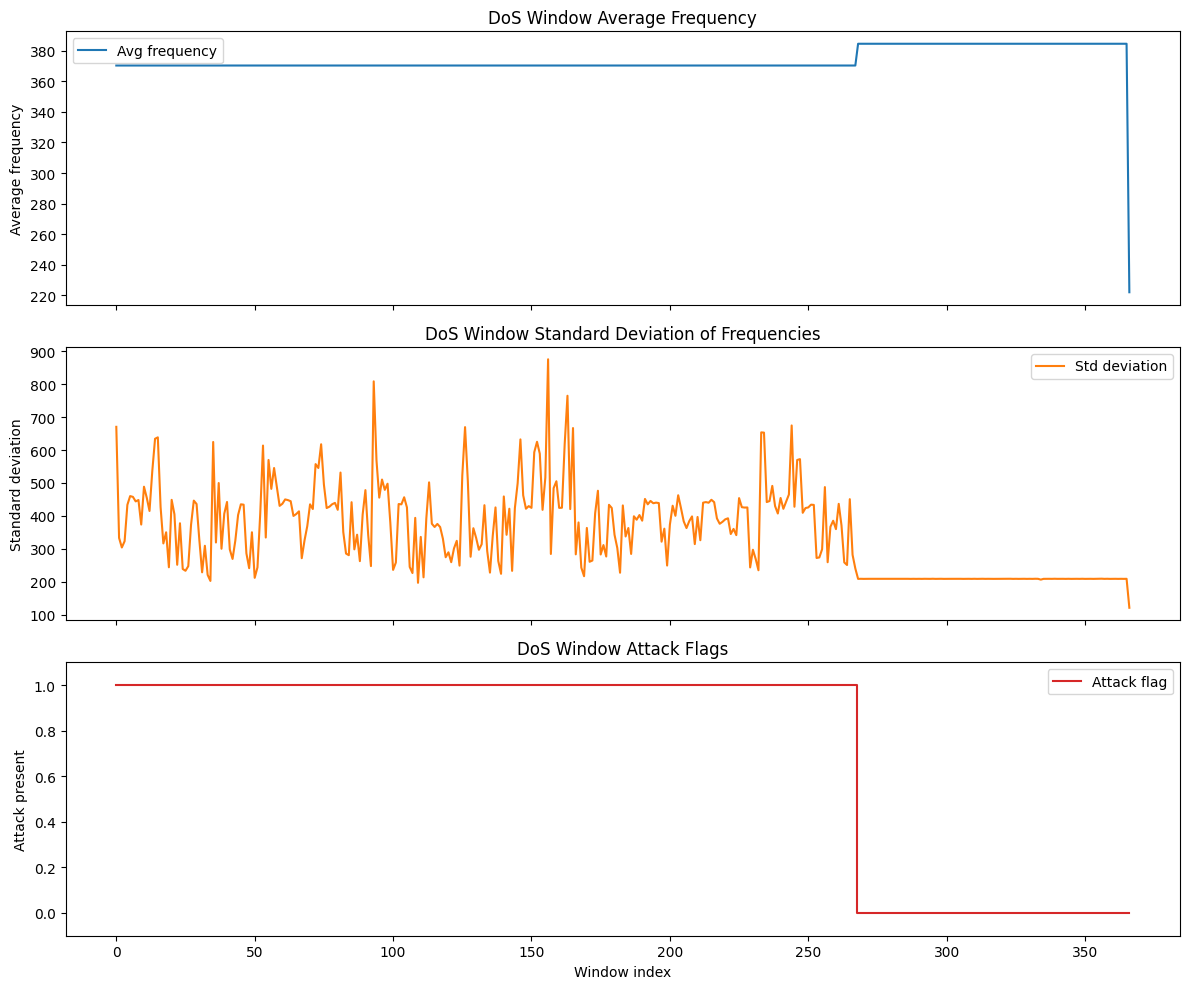

In [142]:
import matplotlib.pyplot as plt

x = range(len(DoS_window_avg_freqs))

fig, axs = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axs[0].plot(x, DoS_window_avg_freqs, color='tab:blue', label='Avg frequency')
axs[0].set_title('DoS Window Average Frequency')
axs[0].set_ylabel('Average frequency')
axs[0].legend()

axs[1].plot(x, DoS_window_std_freqs, color='tab:orange', label='Std deviation')
axs[1].set_title('DoS Window Standard Deviation of Frequencies')
axs[1].set_ylabel('Standard deviation')
axs[1].legend()

axs[2].step(x, DoS_window_attack_flags, where='mid', color='tab:red', label='Attack flag')
axs[2].set_title('DoS Window Attack Flags')
axs[2].set_xlabel('Window index')
axs[2].set_ylabel('Attack present')
axs[2].set_ylim(-0.1, 1.1)
axs[2].legend()

plt.tight_layout()
plt.show()

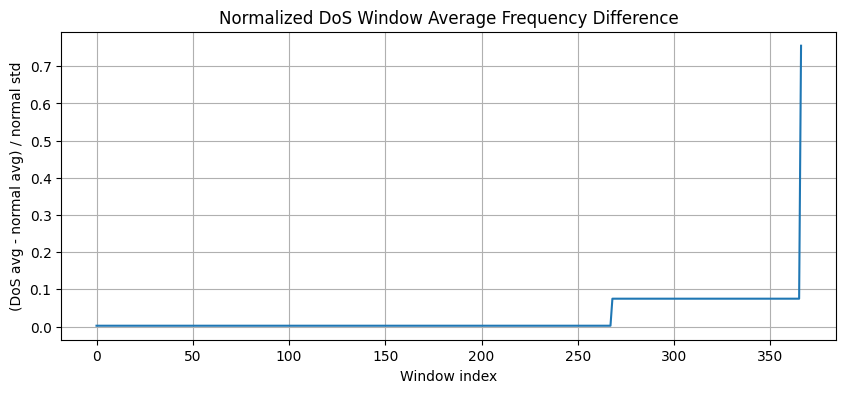

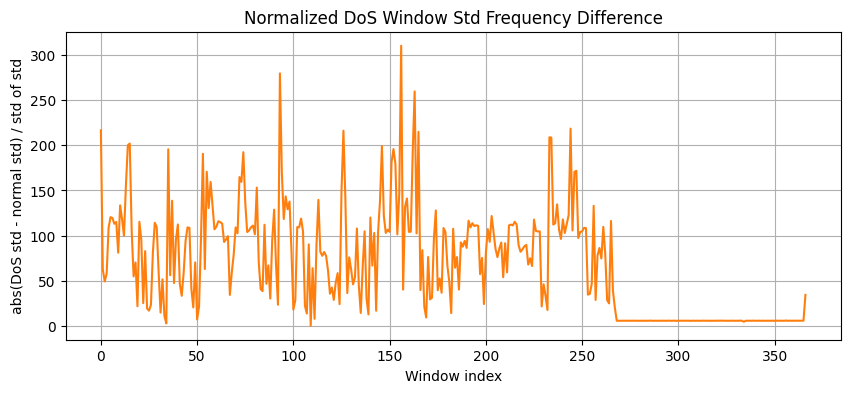

In [143]:
x = range(len(DoS_window_avg_freqs))

dos_avg_norm = [abs(val - avg_window_avg) / avg_window_std for val in DoS_window_avg_freqs]
dos_std_norm = [abs(val - std_window_avg) / std_window_std for val in DoS_window_std_freqs]

plt.figure(figsize=(10, 4))
plt.plot(x, dos_avg_norm, color='tab:blue')
plt.title('Normalized DoS Window Average Frequency Difference')
plt.xlabel('Window index')
plt.ylabel('(DoS avg - normal avg) / normal std')
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(x, dos_std_norm, color='tab:orange')
plt.title('Normalized DoS Window Std Frequency Difference')
plt.xlabel('Window index')
plt.ylabel('abs(DoS std - normal std) / std of std')
plt.grid(True)
plt.show()

In [144]:
Abnormality_Identification = []

for i in range(len(DoS_window_avg_freqs)):
    if abs(DoS_window_avg_freqs[i] - avg_window_avg) / avg_window_std > 1 or abs(DoS_window_std_freqs[i] - std_window_avg) / std_window_std > 10:
        Abnormality_Identification.append(1)
    else:
        Abnormality_Identification.append(0)

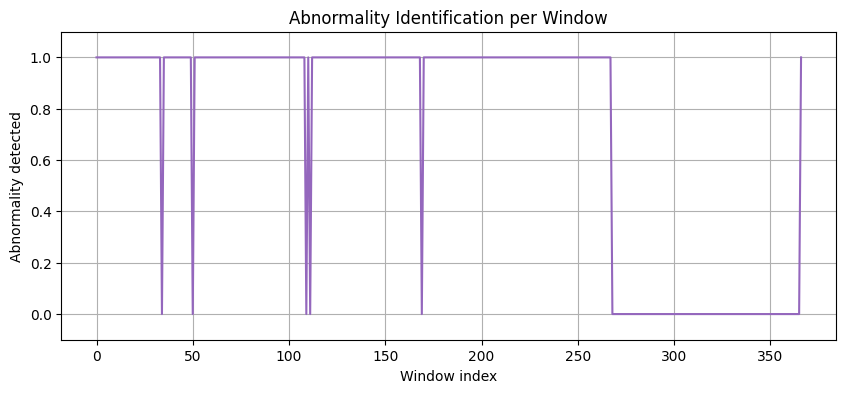

In [145]:
x = range(len(Abnormality_Identification))

plt.figure(figsize=(10, 4))
plt.plot(x, Abnormality_Identification, color='tab:purple')
plt.title('Abnormality Identification per Window')
plt.xlabel('Window index')
plt.ylabel('Abnormality detected')
plt.ylim(-0.1, 1.1)
plt.grid(True)
plt.show()